## Setup
Import dependencies, set seeds, and configure paths and plotting defaults.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scanpy as sc
import seaborn as sns
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
import os
import pandas as pd
import scbiot as scb
from scbiot.utils import set_seed

import harmonypy as hm
from umap import UMAP
# %pip install scib-metrics
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

set_seed(42)

from pathlib import Path
dir = Path.cwd()
print(dir)
parent_dir = dir.parent
print(parent_dir)

from scimorph.theme_publication import theme_publication
from scimorph.utils import set_seed
theme_publication()


## Load
Read the paired multiome dataset from disk.

In [7]:
adata_path = f"{dir}/inputs/multiome.h5ad"
adata = sc.read(
    adata_path,
    backup_url="https://figshare.com/ndownloader/files/59742665"
)



## Preprocess
Split GEX/ATAC modalities and build PCA (RNA) plus LSI (ATAC) features.

In [8]:
# split to gex and peaks
gex_vars = adata.var['feature_types'] == 'GEX'
adata_gex = adata[:, gex_vars].copy()

# Filter for ATAC-related variables
atac_vars = adata.var['feature_types'] == 'ATAC'
adata_atac = adata[:, atac_vars].copy()

In [9]:

# 0) ATAC preprocessing (peak filtering -> LSI -> GA + smoothing)
# figshare link: https://figshare.com/ndownloader/files/59742641
gtf_file = f"{dir}/inputs/gencode.v48.chr_patch_hapl_scaff.basic.annotation.gtf.gz"

adata_ga = scb.pp.create_gene_activity(adata_atac, adata_gex, gtf_file=gtf_file, verbose=True)
adata_ga

Removed 28,633 promoter-proximal peaks (2000bp upstream / 500bp downstream). Remaining: 87,857
Running Iterative LSI iteration 1 ...
Running Iterative LSI iteration 2 ...
[GA] Kept 59,754/86,364 genes by biotype ['protein_coding', 'lncRNA']
[GA] Peaks contigs: 29; Genes contigs: 501; Common: 29
[GA] Using gene field: gene_name
[GA] Built GA with shape (69249, 35570) (cells × genes) from 116,490 peaks.
[names] Harmonized symbols; overlaps (case-insensitive): 11,874


AnnData object with n_obs × n_vars = 69249 × 35570
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker'
    var: 'n_peaks'
    uns: 'provenance'
    layers: 'ga', 'ga_smooth'

In [2]:
import anndata
# adata_gex.write_h5ad('adata_gex.h5ad')
# adata_ga.write_h5ad('adata_ga.h5ad')
# adata_atac.write_h5ad('adata_atac.h5ad')

adata_gex = anndata.read_h5ad('adata_gex.h5ad')
adata_ga = anndata.read_h5ad('adata_ga.h5ad')
adata_atac = anndata.read_h5ad('adata_atac.h5ad')

In [3]:
adata_gex.obs["cell_type"] = adata_gex.obs["cell_type"]
adata_ga.obs["cell_type"] = "Unknown"

adata_gex.X = adata_gex.layers['counts'] 

In [ ]:
adata = scb.pp.autoencoder_map(
    adata_gex, adata_ga,    
    label="modality",    
    # batch_key='batch',
    keys=("reference", "query"),        
    reference_layer="counts",        
    query_layer='ga_smooth',     
    label_key="cell_type",
    unlabeled_category="Unknown",
    out_key="X_ae",           
)
adata

## Integrate
Map the RNA reference and ATAC gene-activity query from the v1.2.0 linear-autoencoder space.

In [ ]:
adata, metrics = scb.ot.integrate(
    adata,
    obsm_key="X_ae",
    batch_key="modality",  
    prealign='ot',
    prealign_strength=0.8,  
    align_reference=True,
    label_key="cell_type",    
    unlabeled_category="Unknown",    
    out_key="X_supbiot"    
)


## Label transfer (supBIOT)


In [ ]:
adata = scb.ot.supbiot(
adata,
use_rep="X_supbiot",
label_key="cell_type",
unlabeled_category="Unknown",
pred_label_key='pred_cell_type',
pred_conf_key="pred_confidence",
min_conf=0.
)

In [7]:
adata_ga = adata[adata.obs['modality'] == 'query'].copy()
adata_gex = adata[adata.obs['modality'] == 'reference'].copy()
adata_ga.obs['pred_cell_type'].value_counts()

pred_cell_type
CD14+ Mono             12230
CD8+ T                 11225
NK                      7343
CD4+ T activated        5824
Naive CD20+ B           5746
CD4+ T naive            5660
Erythroblast            4131
Proerythroblast         3686
Lymph prog              2301
Transitional B          2145
HSC                     1452
B1 B                    1320
pDC                     1083
Normoblast              1058
G/M prog                1043
MK/E prog                914
CD16+ Mono               881
cDC2                     682
CD8+ T naive             223
Plasma cell              162
ID2-hi myeloid prog       82
ILC                       58
Name: count, dtype: int64

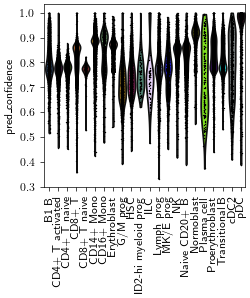

In [8]:
sc.pl.violin(adata_ga, keys="pred_confidence", groupby="pred_cell_type", rotation=90)

In [9]:
sc.pp.neighbors(adata, use_rep="X_supbiot", n_neighbors=50, metric="cosine")
sc.tl.umap(adata, min_dist=0.3, spread=1.0, random_state=0)

## Visualize
Compare batch and Leiden structure across embeddings in UMAP panels.

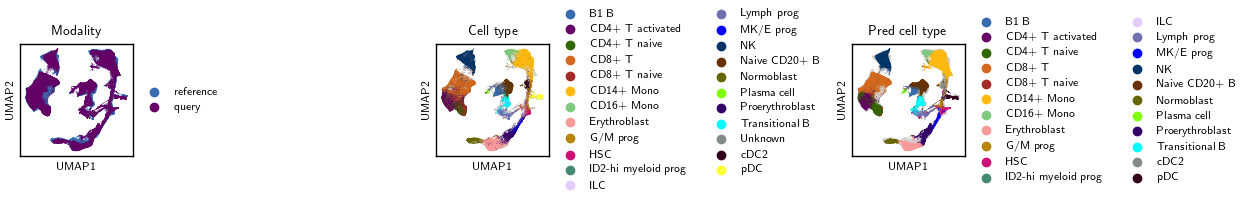

In [10]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import scanpy as sc

sc.settings._vector_friendly = True
mpl.rcParams["axes.edgecolor"] = "black"
mpl.rcParams["axes.linewidth"] = 1.0

def force_border(ax):
    ax.set_axis_on()
    ax.set_frame_on(True)
    ax.patch.set_visible(True)
    for side in ax.spines.values():
        side.set_visible(True)
        side.set_color("black")
        side.set_linewidth(1.0)

def mask_drop_unknown_na(adata, key, drop=("Unknown", "Unkown", "NA", "NaN", "None", "")):
    s = adata.obs[key].astype("string")
    low = s.str.strip().str.lower()
    drop_low = {d.lower() for d in drop}
    m = s.notna() & (~low.isin(drop_low))
    return m.to_numpy(dtype=bool, na_value=False)

methods = ["X_supbiot"]

m_cell = mask_drop_unknown_na(adata, "cell_type")
m_pred = mask_drop_unknown_na(adata, "pred_cell_type")

ncols = 3 * len(methods)
fig, axes = plt.subplots(1, ncols, figsize=(4.2 * ncols, 4.2), squeeze=False)
axes = axes[0]

for i, method in enumerate(methods):
    axL, axM, axR = axes[3*i], axes[3*i + 1], axes[3*i + 2]

    sc.pl.embedding(
        adata, basis="umap", color="modality",
        frameon=True, ax=axL, show=False,
        legend_loc="right margin", legend_fontsize=8, title="Modality"
    )
    axL.set_box_aspect(1)
    axL.set_xlabel("UMAP1"); axL.set_ylabel("UMAP2")
    force_border(axL)

    xlim, ylim = axL.get_xlim(), axL.get_ylim()

    # hide Unknown/NA cells via mask_obs (no slicing -> no view copy issues)
    sc.pl.embedding(
        adata, basis="umap", color="cell_type",
        mask_obs=m_cell, na_in_legend=False,
        frameon=True, ax=axM, show=False,
        legend_loc="right margin", legend_fontsize=8, title="Cell type"
    )
    axM.set_xlim(xlim); axM.set_ylim(ylim)
    axM.set_box_aspect(1)
    axM.set_xlabel("UMAP1"); axM.set_ylabel("UMAP2")
    force_border(axM)

    sc.pl.embedding(
        adata, basis="umap", color="pred_cell_type",
        mask_obs=m_pred, na_in_legend=False,
        frameon=True, ax=axR, show=False,
        legend_loc="right margin", legend_fontsize=8, title="Pred cell type"
    )
    axR.set_xlim(xlim); axR.set_ylim(ylim)
    axR.set_box_aspect(1)
    axR.set_xlabel("UMAP1"); axR.set_ylabel("UMAP2")
    force_border(axR)

plt.tight_layout()

## Evaluate

In [11]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import anndata as ad

def collapse_paired_keep_query_pred(
    adata,
    emb_key="X_supbiot",
    out_key="X_ot",
    modality_key="modality",
    ref_label="reference",
    qry_label="query",
    w_ref=0.5,
    w_qry=0.5,
    pred_type_key="pred_cell_type",
    pred_conf_key_candidates=("pred_confidence", "pred_confidenc"),
    *,
    keep_X=True,
    keep_layers=True,
    keep_obsm=True,
    keep_uns_colors=True,
):
    # --- pull arrays ---
    Xemb = np.asarray(adata.obsm[emb_key], dtype=np.float32)
    mod = adata.obs[modality_key].astype(str)

    # --- pairing id: strip "::reference"/"::query" ---
    cell_id = pd.Index(adata.obs_names).str.replace(r"::.*$", "", regex=True)

    ref_mask = (mod == ref_label).to_numpy()
    qry_mask = (mod == qry_label).to_numpy()

    ref_ids = pd.Index(cell_id[ref_mask])
    qry_ids = pd.Index(cell_id[qry_mask])
    common = ref_ids.intersection(qry_ids)
    if len(common) == 0:
        raise ValueError("No paired cell_ids found between reference and query.")

    # positions in the original stacked adata (aligned to `common`)
    ref_pos = np.flatnonzero(ref_mask)[ref_ids.get_indexer(common)].astype(np.int64, copy=False)
    qry_pos = np.flatnonzero(qry_mask)[qry_ids.get_indexer(common)].astype(np.int64, copy=False)

    # --- fuse embedding ---
    X_fused = (w_ref * Xemb[ref_pos] + w_qry * Xemb[qry_pos]).astype(np.float32)

    # --- build obs (use reference rows as carrier) ---
    obs_ref = adata.obs.iloc[ref_pos].copy()
    obs_ref.index = common.astype(str)

    # --- build X/var ---
    if keep_X:
        X_ref = adata.X[ref_pos, :]
        # copy to detach
        X_ref = X_ref.copy() if sp.issparse(X_ref) else np.asarray(X_ref).copy()
        var = adata.var.copy()
    else:
        X_ref = np.zeros((len(ref_pos), 0), dtype=np.float32)
        var = pd.DataFrame(index=pd.Index([], name=getattr(adata.var_names, "name", None)))

    adata_1n = ad.AnnData(X=X_ref, obs=obs_ref, var=var)

    # --- layers (row-subset only; no obsp involvement) ---
    if keep_layers:
        for k, L in adata.layers.items():
            try:
                Ls = L[ref_pos, :]
                adata_1n.layers[k] = Ls.copy() if sp.issparse(Ls) else np.asarray(Ls).copy()
            except Exception:
                # skip incompatible layers silently
                pass

    # --- obsm (row-subset only) ---
    if keep_obsm:
        for k, M in adata.obsm.items():
            try:
                if getattr(M, "shape", None) is not None and M.shape[0] == adata.n_obs:
                    Ms = M[ref_pos]
                    adata_1n.obsm[k] = Ms.copy() if hasattr(Ms, "copy") else np.asarray(Ms).copy()
            except Exception:
                pass

    # put fused embedding
    adata_1n.obsm[out_key] = X_fused

    # --- copy some useful uns (colors only, avoids neighbors payloads) ---
    if keep_uns_colors:
        for k, v in adata.uns.items():
            if isinstance(k, str) and k.endswith("_colors"):
                try:
                    adata_1n.uns[k] = v.copy() if hasattr(v, "copy") else v
                except Exception:
                    pass

    # --- find which pred_conf column you actually have ---
    pred_conf_key = None
    for k in pred_conf_key_candidates:
        if k in adata.obs:
            pred_conf_key = k
            break

    # --- copy query predictions onto collapsed obs ---
    q_obs = adata.obs.iloc[qry_pos].copy()
    q_obs.index = common.astype(str)

    if pred_type_key in q_obs.columns:
        adata_1n.obs[pred_type_key] = q_obs[pred_type_key].to_numpy()
        # preserve categories if categorical
        if pd.api.types.is_categorical_dtype(q_obs[pred_type_key]):
            adata_1n.obs[pred_type_key] = pd.Categorical(
                adata_1n.obs[pred_type_key],
                categories=q_obs[pred_type_key].cat.categories,
            )

    if pred_conf_key is not None and pred_conf_key in q_obs.columns:
        adata_1n.obs[pred_conf_key] = q_obs[pred_conf_key].to_numpy()

    return adata_1n


# usage
adata_1n = collapse_paired_keep_query_pred(
    adata,
    emb_key="X_supbiot",
    out_key="X_ot",
    w_ref=0.5,
    w_qry=0.5,
)

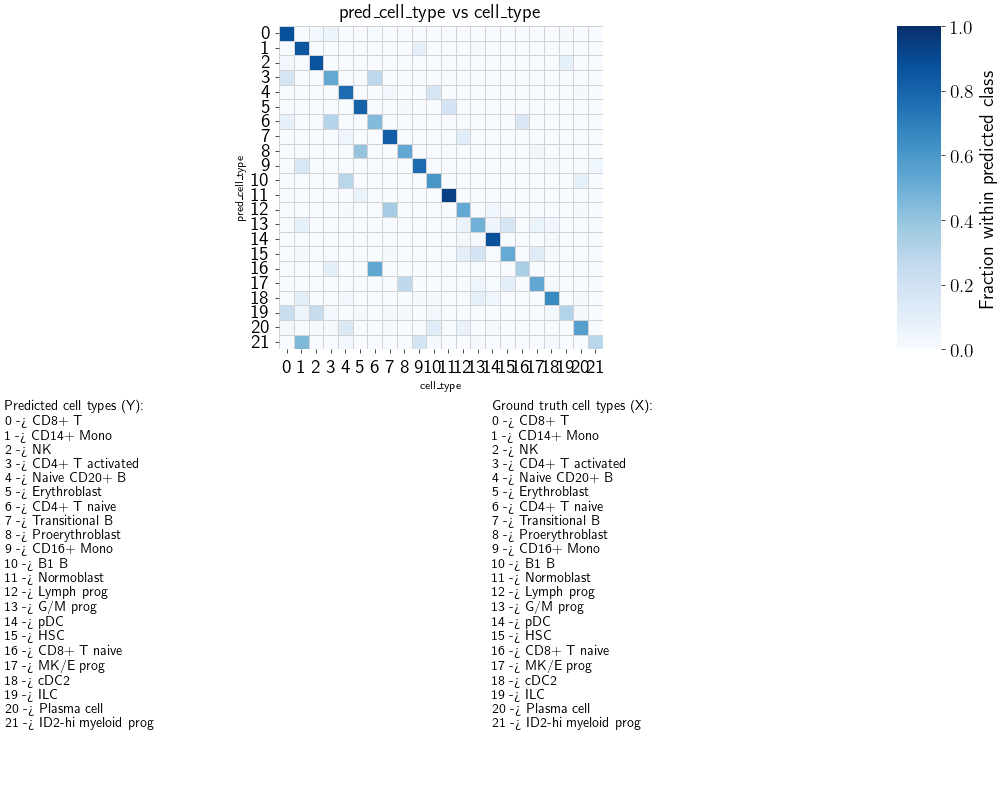

In [12]:
fig, ax, counts_df, norm_df = scb.pl.plot_anndata_confusion(
    adata_1n,
    true_key="cell_type",
    pred_key="pred_cell_type",
    drop_unknown=False,          # key line
    normalize="pred",
    annotate_mapping=True,
    return_data=True,
)

In [13]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

# 1) Robustify embedding (median/MAD + clipping)
X = adata_1n.obsm["X_ot"].astype(np.float32, copy=True)
med = np.median(X, axis=0)
mad = np.median(np.abs(X - med), axis=0) + 1e-9
Z = (X - med) / (1.4826 * mad)
Z = np.clip(Z, -5, 5).astype(np.float32)
adata_1n.obsm["X_ae_robust"] = Z

# 2) kNN outlier score (mean distance)
k = 30
nbrs = NearestNeighbors(n_neighbors=k).fit(Z)
d, _ = nbrs.kneighbors(Z)
knn_mean = d[:, 1:].mean(1)

# 3) Flag outliers within each reference cell type
ref_mask = adata_1n.obs["cell_type"].to_numpy() != "Unknown"
cell_type = adata_1n.obs["cell_type"].to_numpy()
outlier = np.zeros(len(adata_1n), dtype=bool)

for ct in np.unique(cell_type[ref_mask]):
    idx = np.where(ref_mask & (cell_type == ct))[0]
    if idx.size < 30:  # don’t prune tiny groups
        continue
    thr = np.quantile(knn_mean[idx], 0.98)  # adjust 0.98–0.995
    outlier[idx] = knn_mean[idx] > thr

# 4) Relabel outlier reference cells so they’re not fixed anchors
adata_1n.obs.loc[outlier, "cell_type"] = "Unknown"
adata_1n.obs['cell_type'].value_counts()


cell_type
CD8+ T                 11357
CD14+ Mono             10626
NK                      6790
CD4+ T activated        5415
Naive CD20+ B           4950
Erythroblast            4817
CD4+ T naive            4310
Transitional B          2753
Proerythroblast         2254
CD16+ Mono              1856
B1 B                    1852
Normoblast              1744
Lymph prog              1743
Unknown                 1395
G/M prog                1178
pDC                     1167
HSC                     1050
CD8+ T naive             991
MK/E prog                866
cDC2                     841
ILC                      818
Plasma cell              371
ID2-hi myeloid prog      105
Name: count, dtype: int64

In [ ]:
adata, metrics = scb.ot.integrate(
    adata_1n,
    obsm_key="X_ot",
    batch_key="batch",     
    label_key="cell_type",    
    unlabeled_category="Unknown",    
    out_key="X_supbiot2"    
)


In [15]:
from sklearn.metrics import normalized_mutual_info_score

y_true = adata_1n.obs["cell_type"].astype(str)
y_pred = adata_1n.obs["pred_cell_type"].astype(str)

# keep only valid rows
mask = y_true.notna() & y_pred.notna()

# (optional) ignore "unknown" labels
# mask &= (y_true != "unknown") & (y_pred != "unknown")

nmi = normalized_mutual_info_score(
    y_true[mask].to_numpy(),
    y_pred[mask].to_numpy(),
    average_method="arithmetic",
)

print(f"NMI = {nmi:.6f}")

NMI = 0.705543


In [17]:
methods = ["X_supbiot2"] # , "scBIOT_OT"
leiden_methods = [f'{method}_leiden' for method in methods]

for method, leiden_method in zip(methods, leiden_methods):
    sc.pp.neighbors(adata_1n, use_rep=method)
    sc.tl.umap(adata_1n)
    adata.obsm[f"X_umap_{method}"] = adata.obsm["X_umap"].copy()
    sc.tl.leiden(adata_1n, key_added=leiden_method, resolution=0.8)

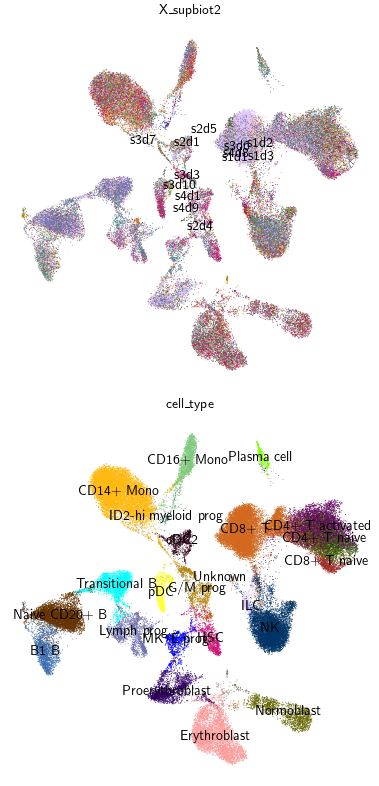

In [18]:
import matplotlib.pyplot as plt
import scanpy as sc


# 2 rows x len(methods) columns
fig, axes = plt.subplots(
    2,
    len(methods),
    figsize=(4 * len(methods), 8),
    squeeze=False  # ensures axes is a 2D array
)

for col, method in enumerate(methods):
    # 1) Top row (row=0): color by "batch"
    sc.pl.embedding(
        adata_1n,
        basis=f"X_umap_{method}",  # The coordinates stored in adata.obsm["X_umap_{method}"]
        color="batch",            # Assume adata.obs["batch"] exists
        frameon=False,
        ax=axes[0, col],
        show=False,
        legend_loc="on data",
        legend_fontsize=10,  # smaller font
        title=f"{method}"
    )

    # 2) Bottom row (row=1): color by the Leiden clusters for this method
    leiden_key = f"{method}_leiden"
    sc.pl.embedding(
        adata_1n,
        basis=f"X_umap_{method}",
        color='cell_type',         # Column in adata.obs
        frameon=False,
        ax=axes[1, col],
        show=False,
        legend_loc="on data",
        legend_fontsize=10,  # smaller font
        # title=f"{method}"
    )

plt.tight_layout()
# fig.savefig("batch_and_leiden_per_embedding.pdf", dpi=300)
# plt.close(fig)


Embeddings: 100%|██████████| 4/4 [02:33<00:00, 38.27s/it]


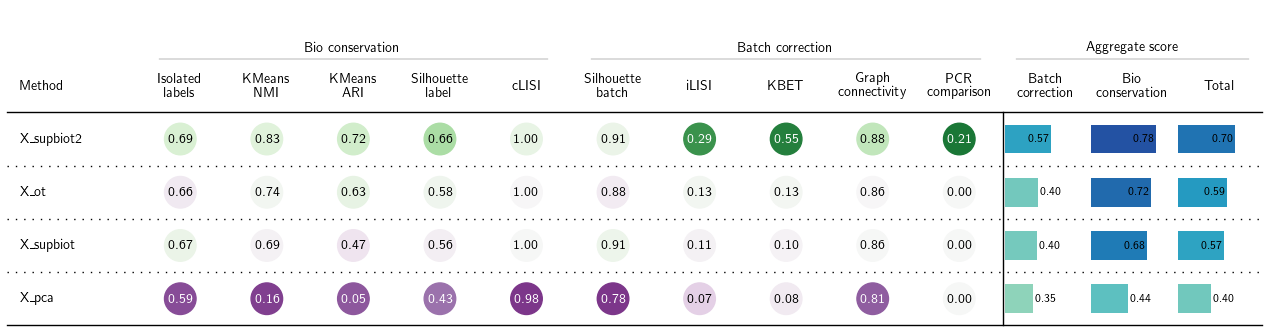

In [16]:
bm = Benchmarker(
    adata_1n, 
    batch_key="batch",
    label_key="cell_type",
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),    
    embedding_obsm_keys=["X_pca", "X_supbiot", "X_ot", "X_supbiot2"], 
    n_jobs=32
    
)
bm.benchmark()
bm.plot_results_table(min_max_scale=False)